# Binning Post-Processing

Idea: 

After the parameter space is binned, for each bin a CDF fit is performed and this goes for a series of spectral indices we test. Fitting the parameter space comes not without some problems:

- Some bins are sparsly populated and thus are left empty (insufficient number of events). 
- In some bins, the fit fails.
- In some bins, the fit goes through, but the fit does not represent the actual physics in this region. either the bin is too large and contains a convolution of multiple King's or just the distributions in the bin has bad statistics.

In the LLH we place events in the parameter space, assuming some spectral index, trying to read of the values of alpha/beta we need. We do:

1. NN search in one parameterization space for one spectral index. 
1. Then use the same bin index for all other spectral indices. Interpolation in the spectral index direction 

With this method, I expect essentially two major problems: 
- Because of sparse population of the parametrization space, sometimes large regions of the space are left unfitted. With NN search we run into taking alpha, beta values from far away bins where the properties could be very different.
- Some bins get a bad, unphysical fit. In this bin, reading of the parameter values leads to taking wrong, sometimes veeery wrong parameters. even worse, when doing linear interpolation across spectral indices, they distort the other values immensly if the deviation is large.

This is why I would like to try out two post-fit steps to increase the stability of the method and make it less prone to these two effects.

1. **Removing parameter value outliers** In the parameter space we expect the parameters to evolve smoothly. Removing statistical outliers, thus extreme values compared to the others could be an easy fix.

2. **Dealing with big voids** Big voids in the parameter space could be problematic when using NN-search. Some sort of interpolation would be better. 

3. **Smoothing parameter space** Even after outlier removal and interpolation of voids there could be still room for improvement. What about smoothing the paramter space bins to a tiny resolution and then rebin with a smaller resolution than before? 

In this notebook i want to try to implement all three of the postprocessing methods individually. Looking into the improvements after the postprocessing will be investigated seperatly.

In [2]:
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np 
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../../../"))
import csky as cy
from pathlib import Path
import pickle
from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
import kingmaker_fork.likelihood_analysis.analysis_helpers.fitting_plots as fplt
from kingmaker_fork.likelihood_analysis.analysis_helpers.rms_fit_quality import cdf_rms
from kingmaker_fork.likelihood_analysis.analysis_helpers.get_bin_egdes import get_bin_info



import inspect

if not hasattr(inspect, "getargspec"):
    inspect.getargspec = inspect.getfullargspec
from csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu

## 0. Reloading a Fit

In [3]:
#get cached fits:
run_folder = Path('/data/user/fkrafft/split_sky_trials')
fitting_candidate = 'E5_D4_902b96_S10_MC300'
sky_candidate = 'south'
fitting_candidate_sin_dec = -0.5

candidate_id = f"SINDEC_{fitting_candidate_sin_dec}_NTRIALS_{1000}_{fitting_candidate}"
config_dir = os.path.join(run_folder, sky_candidate, fitting_candidate, f"king_trial_runner_config_sindec_{fitting_candidate_sin_dec}_{candidate_id}.pkl")

In [4]:
with open(config_dir, "rb") as f:
        cfg = pickle.load(f)
out_dir = os.path.join(run_folder, sky_candidate, fitting_candidate)
fit_cache_path = os.path.join(out_dir, sky_candidate, cfg["fit_cache_filename"])

ana_dir = cy.utils.ensure_dir(f'/data/user/fkrafft/split_sky_trials/{sky_candidate}')

repo = cy.selections.Repository(
    local_root = '/data/user/fkrafft/gfu_data_sky_split',
    remote_root= '/data/user/fkrafft/gfu_data_sky_split')

for name in ["root", "local_root", "remote_root", "base_dir", "dir"]:
    print(name, "=", getattr(repo, name, None))

if sky_candidate == 'north':
    gfu_sky_spcs = custom_gfu.north_gfu_19_to_23
elif sky_candidate == 'south':
    gfu_sky_spcs = custom_gfu.south_gfu_19_to_23
else:
    raise ValueError(f'Unknown sky split (not `south` nor `north`): {sky_candidate}')

ana = cy.get_analysis(repo, 'version-001-p09' , gfu_sky_spcs, dir = ana_dir)


root = None
local_root = /data/user/fkrafft/gfu_data_sky_split
remote_root = /data/user/fkrafft/gfu_data_sky_split
base_dir = None
dir = None
Setting up Analysis for:
GFU_2019_2023_south
Setting up GFU_2019_2023_south...
Reading /data/user/fkrafft/gfu_data_sky_split/south/IC86_2023_MC.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/IC86_2019_data.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/IC86_2020_data.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/IC86_2021_data.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/IC86_2022_data.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/GRL/IC86_2019_data.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/GRL/IC86_2020_data.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/GRL/IC86_2021_data.npy ...
Reading /data/user/fkrafft/gfu_data_sky_split/south/GRL/IC86_2022_data.npy ...
Energy PDF Ratio Model...
  * gamma = 4.0000 ...
Signal Acceptance Model...
  * gamma = 4.

In [5]:

with open(config_dir, "rb") as f:
    cfg = pickle.load(f)

out_dir = cfg["out_dir"]
gamma = cfg["gamma"]
gamma_idx = list(cfg['spectral_indices']).index(gamma)
src_sin_dec = cfg["src_sin_dec"]

fit_cache_filename = f"king_fit_custom_gfu_{candidate_id}.npz"
king_wrapper = KingSpatialLikelihood(
                                    signal_events = ana[0].sig.as_array,
                                    parametrization_bins = cfg['parametrization_bins'],
                                    spectral_indices= cfg['spectral_indices'],
                                    cache_name = os.path.join(out_dir, fit_cache_filename),
                                    dpsi_nbins=cfg['dpsi_nbins'],
                                    minimum_counts=cfg['minimum_counts'],
                                    weight_field = cfg['weight_field'],
                                    true_ra_name="true_ra",
                                    true_dec_name="true_dec",
                                    true_energy_name="true_energy",
                                    angular_cutoff=np.radians(cfg["angular_cutoff_deg"]),
                                       )
dec = np.arcsin(src_sin_dec)
srcs = cy.sources(0, dec)

NOTE: Using cached King parameters...


### 0.1 Visualization of raw fit

In [6]:


fit_parameters = king_wrapper.fitted_parameters

alpha_vals = fit_parameters["alpha"][gamma_idx]
beta_vals = fit_parameters["beta"][gamma_idx]
event_counts = fit_parameters["event_counts"][gamma_idx]
fit_quality_chi2 = fit_parameters["fit_quality"][gamma_idx]
fit_cdf_rms = cdf_rms(
    fit_parameters,
    king_wrapper.king_pdf,
    gamma_idx=gamma_idx,
    minimum_counts=cfg['minimum_counts'],
)[gamma_idx]

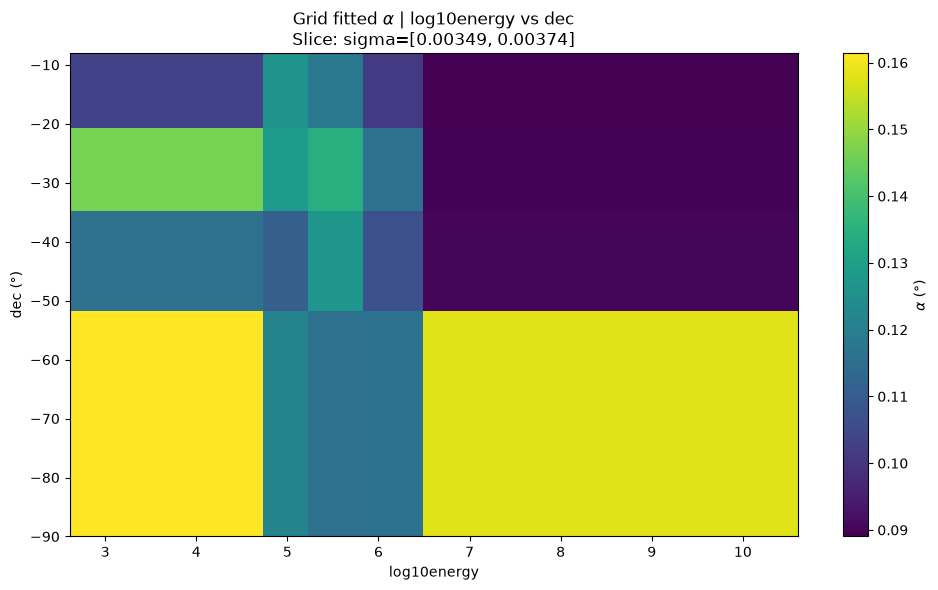

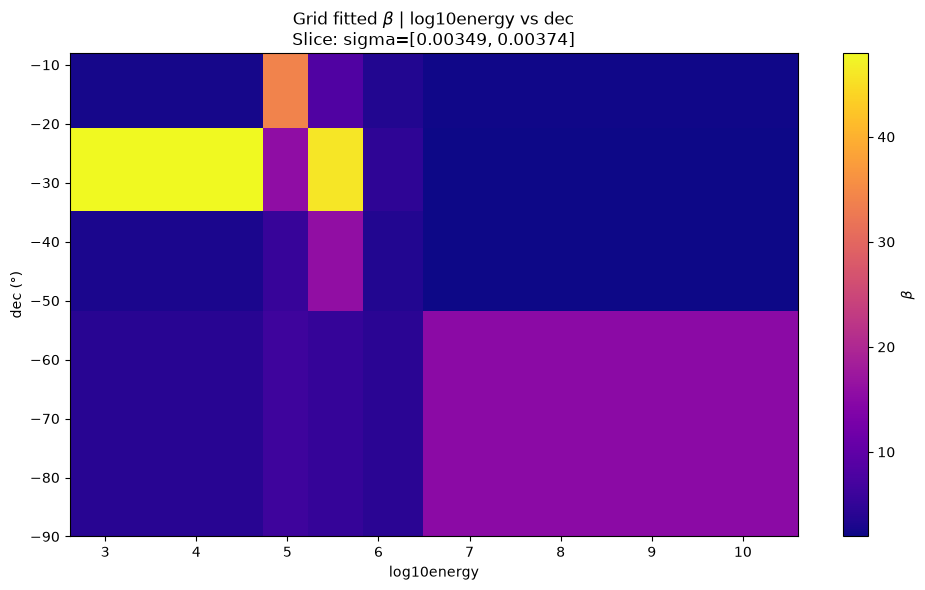

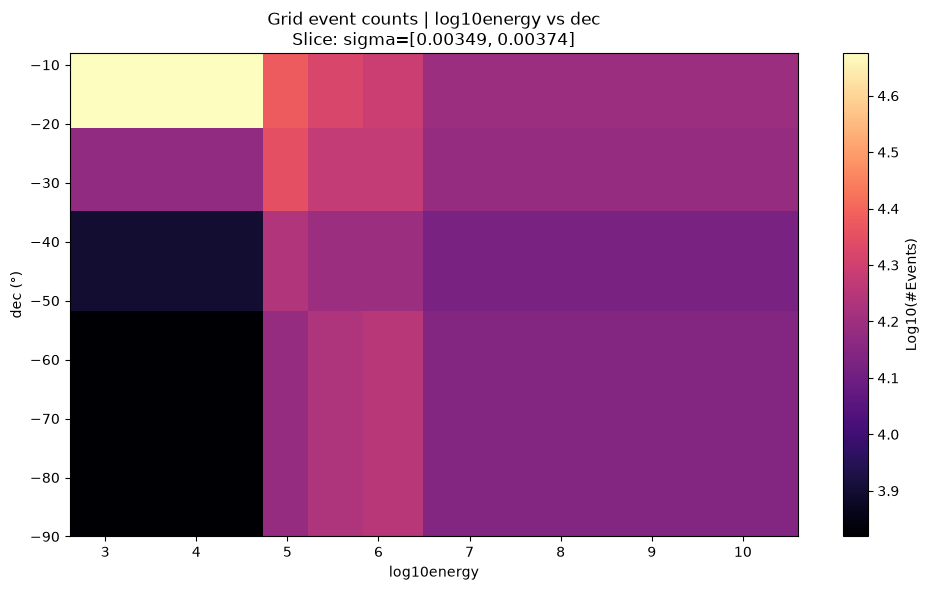

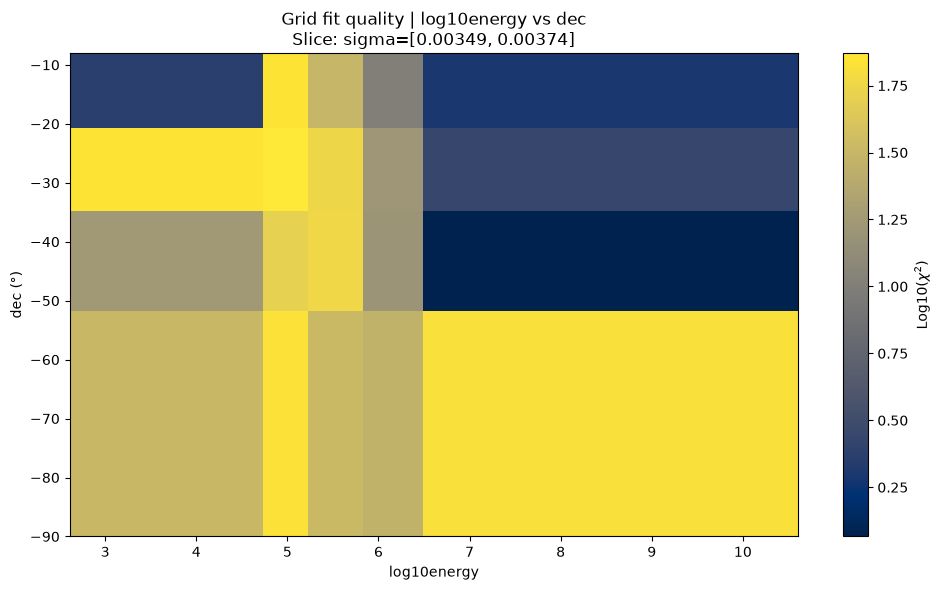

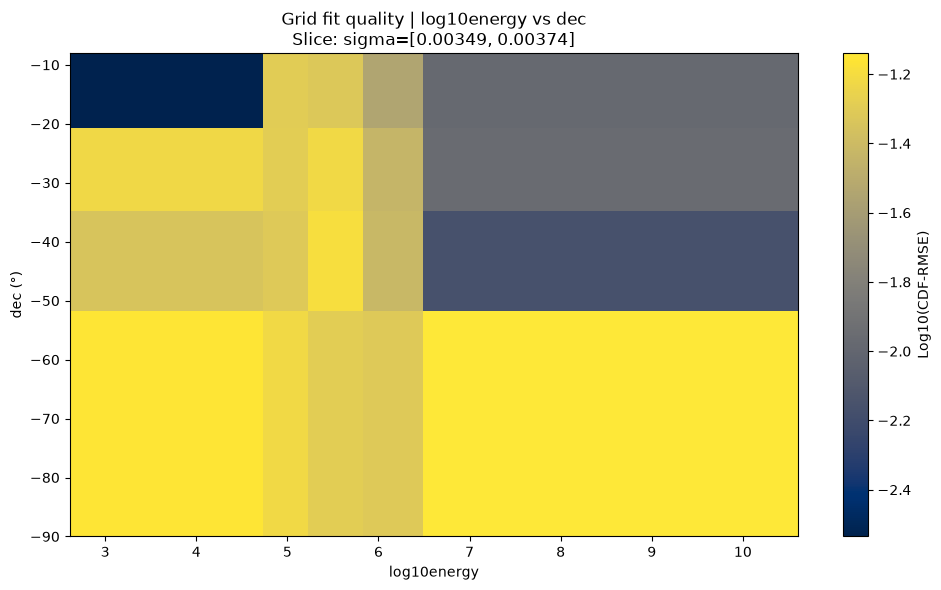

<Axes: title={'center': 'Grid fit quality | log10energy vs dec\nSlice: sigma=[0.00349, 0.00374]'}, xlabel='log10energy', ylabel='dec (°)'>

In [7]:
hidden_value = np.deg2rad(0.1)
angerr_bins = fit_parameters["parametrization_bins"].item()["sigma"]

angerr_idx = np.digitize(hidden_value, angerr_bins) - 1
angerr_idx = np.clip(angerr_idx, 0, len(angerr_bins) - 2)

angerr_idx = 4

hidden_slices = {"sigma": angerr_idx}

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="dec",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | log10energy vs dec",
    cbar_label="$\\alpha$ (°)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="dec",
    values=beta_vals,
    title="Grid fitted $\\beta$ | log10energy vs dec",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    log_values= True,
    y_name="dec",
    values=event_counts,
    title="Grid event counts | log10energy vs dec",
    cbar_label="Log10(#Events)",
    cmap="magma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="dec",
    values=fit_quality_chi2,
    title="Grid fit quality | log10energy vs dec",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="dec",
    values=fit_cdf_rms,
    title="Grid fit quality | log10energy vs dec",
    cbar_label="Log10(CDF-RMSE)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    hidden_slices=hidden_slices,
)

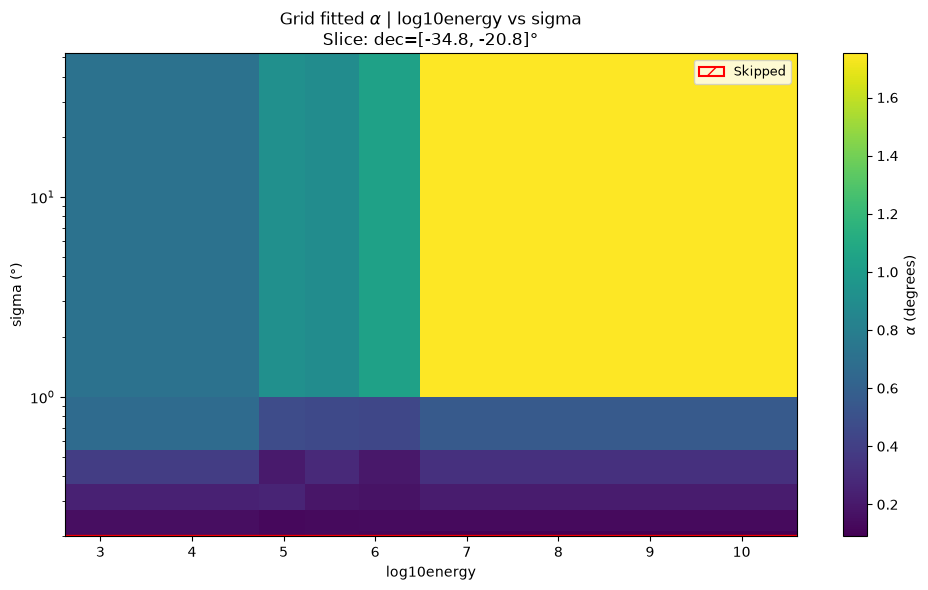

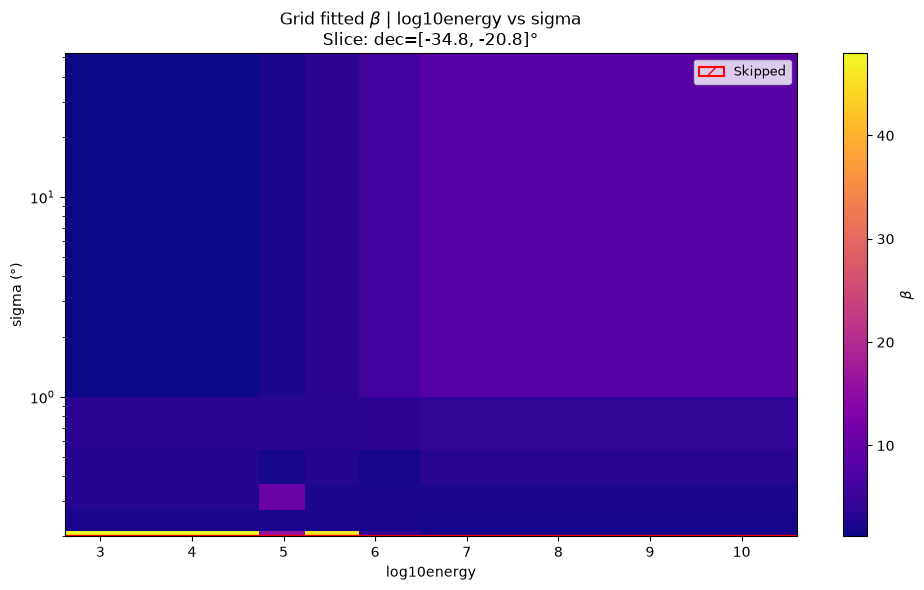

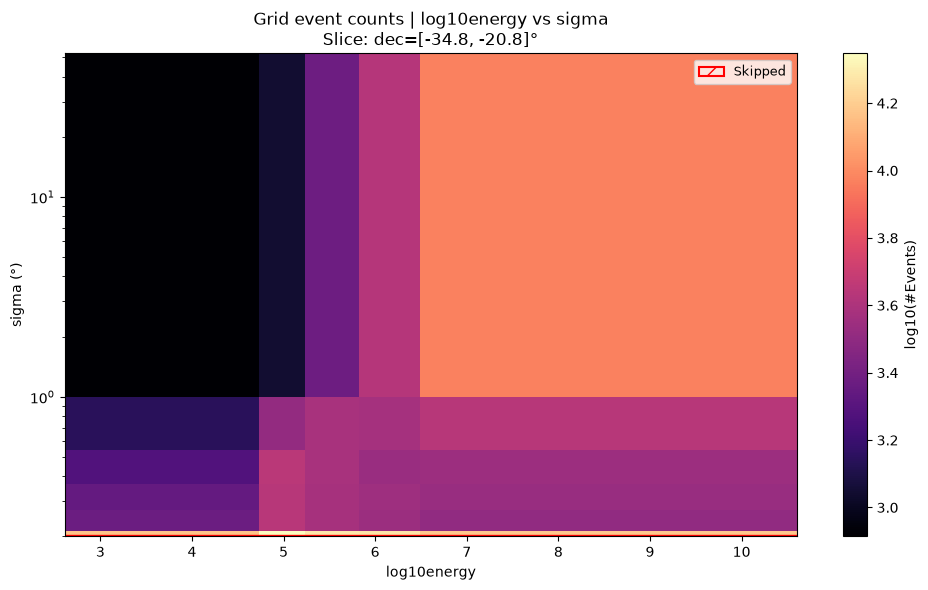

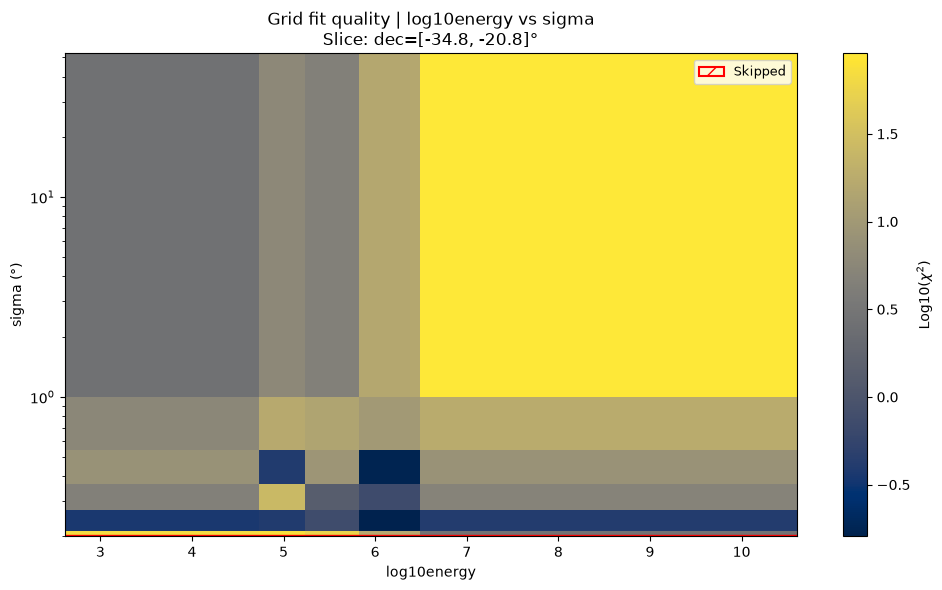

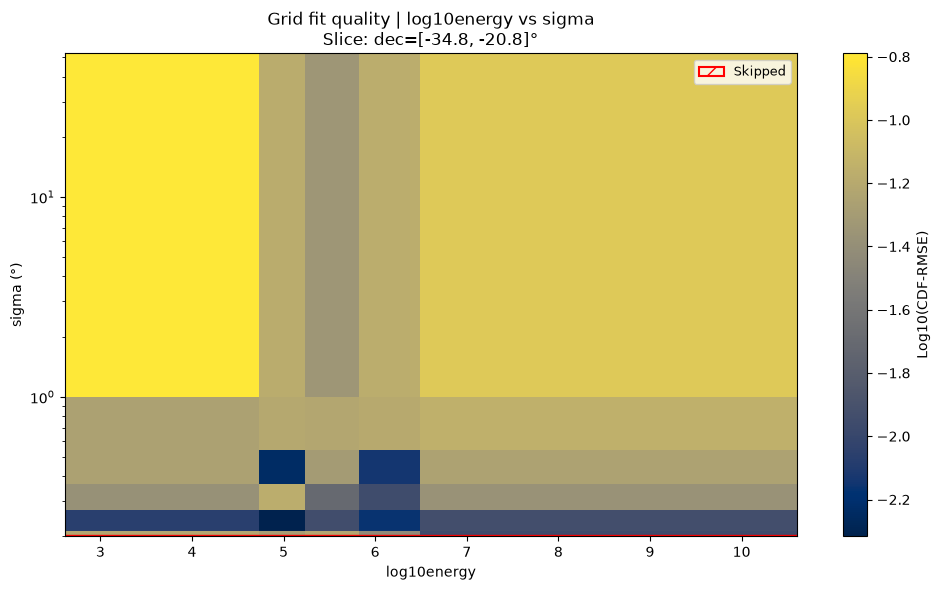

<Axes: title={'center': 'Grid fit quality | log10energy vs sigma\nSlice: dec=[-34.8, -20.8]°'}, xlabel='log10energy', ylabel='sigma (°)'>

In [8]:
dec_bins = cfg["parametrization_bins"]["dec"]
dec_idx = 2
#dec_idx = len(dec_bins) // 2 - 1

hidden_slices = {"dec": dec_idx}

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | log10energy vs sigma",
    cbar_label="$\\alpha$ (degrees)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,

)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=beta_vals,
    title="Grid fitted $\\beta$ | log10energy vs sigma",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=event_counts,
    title="Grid event counts | log10energy vs sigma",
    cbar_label="log10(#Events)",
    cmap="magma",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,

)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=fit_quality_chi2,
    title="Grid fit quality | log10energy vs sigma",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=fit_cdf_rms,
    title="Grid fit quality | log10energy vs sigma",
    cbar_label="Log10(CDF-RMSE)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

a healthy bin

Found 120 bins with stored fits
Showing best bins:
1: bin=(3, 2, 5), CDF_chi2=0.160


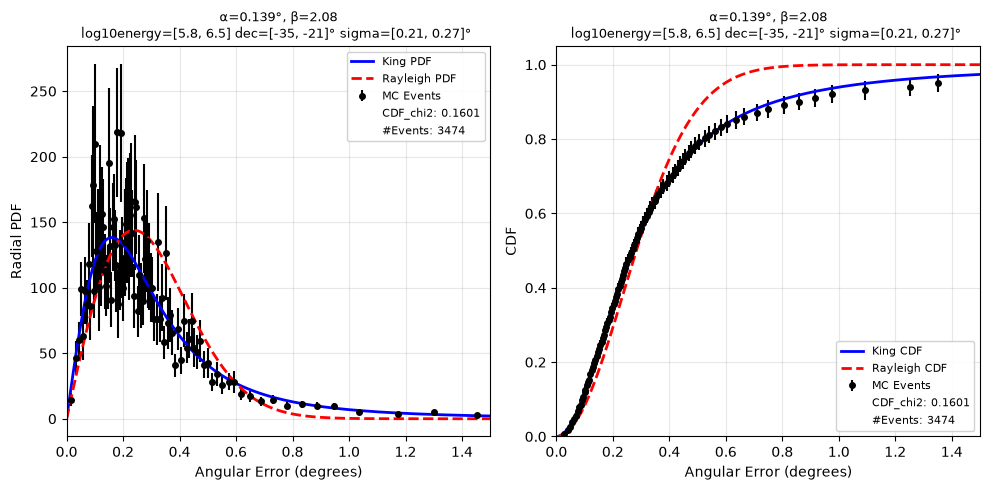

[((3, 2, 5), np.float64(0.16014003915133113))]

In [9]:
bin_indices = [3,2, 5]
fplt.plot_selected_fit_bins(
    
    fit_parameters,
    figsize= (10, 5),
    mode="best",
    metric = 'CDF_chi2',
    x_log = False,
    y_log = False,
    normalize_fit_to_hist= False,
    plot_kind= 'radial',
    gamma_idx= gamma_idx,
    n_plots=1,
    show_data= True,
    minimum_counts=cfg['minimum_counts'],
    show_rayleigh_ref = True, 
    signal_events = ana[0].sig.as_array,
    king_pdf = king_wrapper.king_pdf,
    selected_bin_idx= bin_indices,
    curve_kind= 'both',
    x_lim = 1.5
    )

Found 120 bins with stored fits
Showing best bins:
1: bin=(0, 3, 4), CDF_RMS=0.003
2: bin=(1, 3, 5), CDF_RMS=0.004
3: bin=(1, 2, 5), CDF_RMS=0.005
4: bin=(2, 3, 7), CDF_RMS=0.005
5: bin=(0, 0, 5), CDF_RMS=0.005
6: bin=(2, 3, 6), CDF_RMS=0.005
7: bin=(1, 1, 6), CDF_RMS=0.006
8: bin=(1, 1, 5), CDF_RMS=0.006


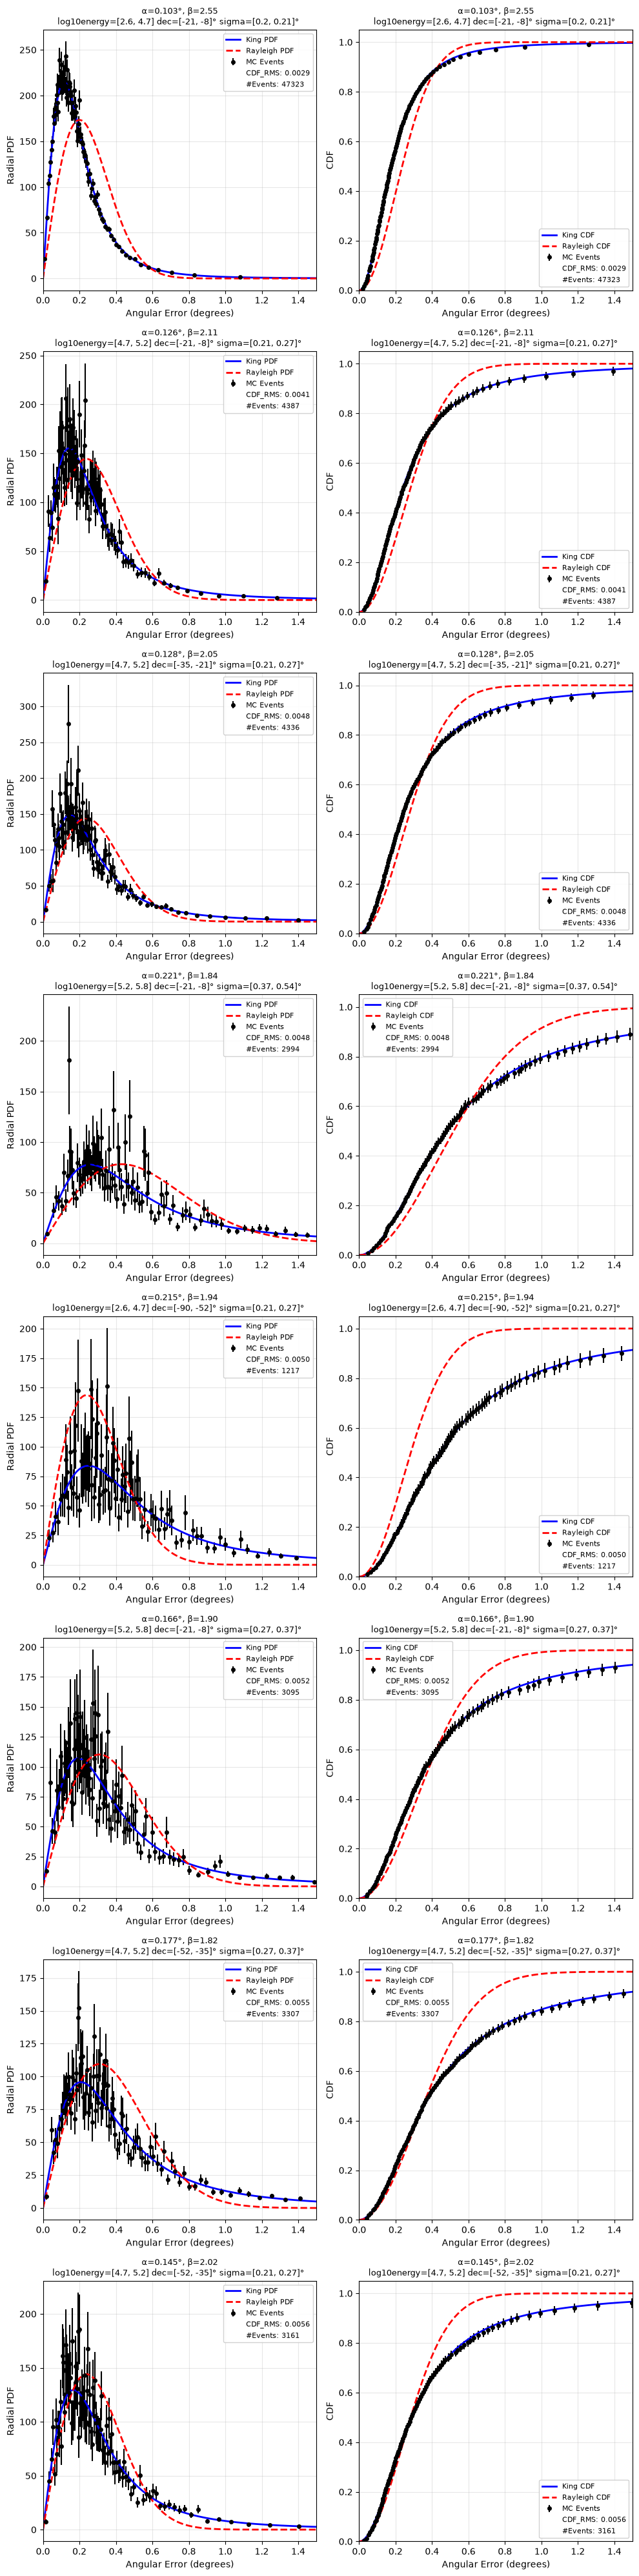

[((0, 3, 4), np.float64(0.0029164708199403075)),
 ((1, 3, 5), np.float64(0.004139420260251651)),
 ((1, 2, 5), np.float64(0.0048199067780872054)),
 ((2, 3, 7), np.float64(0.00484206322814747)),
 ((0, 0, 5), np.float64(0.004982707238853064)),
 ((2, 3, 6), np.float64(0.005156703771260031)),
 ((1, 1, 6), np.float64(0.005514589127784499)),
 ((1, 1, 5), np.float64(0.005553239851461742))]

In [20]:
fplt.plot_selected_fit_bins(
    
    fit_parameters,
    figsize= (10, 40),
    mode="best",
    metric = 'CDF_RMS',
    x_log = False,
    y_log = False,
    normalize_fit_to_hist= False,
    plot_kind= 'radial',
    gamma_idx= gamma_idx,
    n_plots=8,
    show_data= True,
    minimum_counts=cfg['minimum_counts'],
    show_rayleigh_ref = True, 
    signal_events = ana[0].sig.as_array,
    king_pdf = king_wrapper.king_pdf,
    curve_kind= 'both',
    x_lim = 1.5
    )

some unhealthy bins:

Found 120 bins with stored fits
Showing best bins:
1: bin=(4, 2, 9), CDF_chi2=91.004


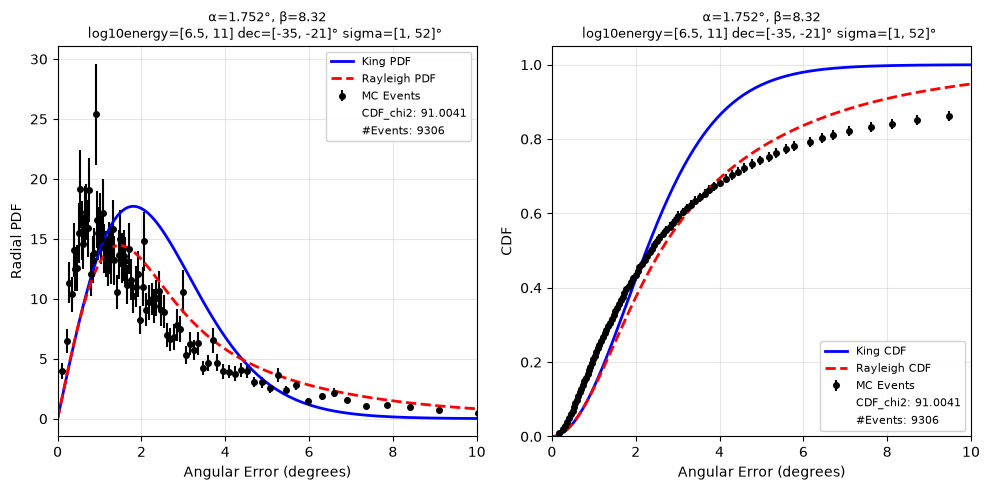

[((4, 2, 9), np.float64(91.00410954071151))]

In [10]:
bin_indices = [4,2, 9]

fplt.plot_selected_fit_bins(
    
    fit_parameters,
    figsize= (10, 5),
    mode="best",
    metric = 'CDF_chi2',
    x_log = False,
    y_log = False,
    normalize_fit_to_hist= False,
    plot_kind= 'radial',
    gamma_idx= gamma_idx,
    n_plots=1,
    show_data= True,
    minimum_counts=cfg['minimum_counts'],
    show_rayleigh_ref = True, 
    signal_events = ana[0].sig.as_array,
    king_pdf = king_wrapper.king_pdf,
    selected_bin_idx= bin_indices,
    curve_kind= 'both',
    x_lim = 10
    )
#get_bin_info(fit_parameters["parametrization_bins"], bin_indices)

Found 120 bins with stored fits
Showing best bins:
1: bin=(0, 2, 4), CDF_chi2=68.898


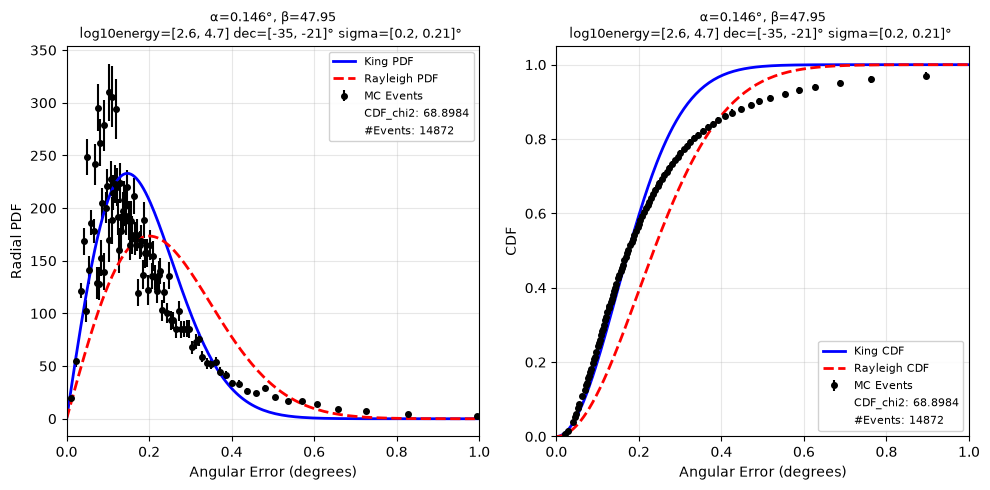

[((0, 2, 4), np.float64(68.89836656243837))]

In [11]:
bin_indices = [0,2, 4]
fplt.plot_selected_fit_bins(
    
    fit_parameters,
    figsize= (10, 5),
    mode="best",
    metric = 'CDF_chi2',
    x_log = False,
    y_log = False,
    normalize_fit_to_hist= False,
    plot_kind= 'radial',
    gamma_idx= gamma_idx,
    n_plots=1,
    show_data= True,
    minimum_counts=cfg['minimum_counts'],
    show_rayleigh_ref = True, 
    signal_events = ana[0].sig.as_array,
    king_pdf = king_wrapper.king_pdf,
    selected_bin_idx= bin_indices,
    curve_kind= 'both',
    x_lim = 1
    )

Found 120 bins with stored fits
Showing worst bins:
1: bin=(4, 2, 9), CDF_chi2=91.004
2: bin=(1, 2, 4), CDF_chi2=74.174
3: bin=(0, 2, 4), CDF_chi2=68.898
4: bin=(1, 3, 4), CDF_chi2=68.667
5: bin=(1, 0, 4), CDF_chi2=66.661
6: bin=(4, 0, 4), CDF_chi2=65.493
7: bin=(2, 1, 4), CDF_chi2=56.992
8: bin=(0, 3, 9), CDF_chi2=56.767
9: bin=(2, 2, 4), CDF_chi2=56.016
10: bin=(1, 1, 4), CDF_chi2=50.790
11: bin=(0, 3, 7), CDF_chi2=44.851
12: bin=(0, 3, 6), CDF_chi2=36.057
13: bin=(4, 1, 9), CDF_chi2=34.586
14: bin=(0, 3, 5), CDF_chi2=34.151
15: bin=(2, 0, 4), CDF_chi2=32.894
16: bin=(0, 0, 4), CDF_chi2=32.020
17: bin=(2, 3, 4), CDF_chi2=31.366
18: bin=(4, 0, 9), CDF_chi2=30.634
19: bin=(3, 0, 8), CDF_chi2=29.585
20: bin=(3, 0, 4), CDF_chi2=28.928
21: bin=(4, 0, 8), CDF_chi2=26.047
22: bin=(1, 2, 6), CDF_chi2=25.869
23: bin=(2, 1, 7), CDF_chi2=23.761
24: bin=(1, 0, 7), CDF_chi2=21.596
25: bin=(4, 1, 8), CDF_chi2=20.251
26: bin=(4, 0, 7), CDF_chi2=18.075
27: bin=(2, 0, 7), CDF_chi2=17.798
28: bin=(0, 



[((4, 2, 9), np.float64(91.00410954071151)),
 ((1, 2, 4), np.float64(74.17417287263589)),
 ((0, 2, 4), np.float64(68.89836656243837)),
 ((1, 3, 4), np.float64(68.66716809408483)),
 ((1, 0, 4), np.float64(66.66078271161544)),
 ((4, 0, 4), np.float64(65.49269317632493)),
 ((2, 1, 4), np.float64(56.99162550265066)),
 ((0, 3, 9), np.float64(56.76664380708722)),
 ((2, 2, 4), np.float64(56.01605615932544)),
 ((1, 1, 4), np.float64(50.78972547057913)),
 ((0, 3, 7), np.float64(44.85082886928792)),
 ((0, 3, 6), np.float64(36.05687812966016)),
 ((4, 1, 9), np.float64(34.58634526273741)),
 ((0, 3, 5), np.float64(34.15106727921707)),
 ((2, 0, 4), np.float64(32.894367578413444)),
 ((0, 0, 4), np.float64(32.019974487756826)),
 ((2, 3, 4), np.float64(31.366476028066668)),
 ((4, 0, 9), np.float64(30.634104364389312)),
 ((3, 0, 8), np.float64(29.585048907700898)),
 ((3, 0, 4), np.float64(28.9276138315418)),
 ((4, 0, 8), np.float64(26.046794630400672)),
 ((1, 2, 6), np.float64(25.869065570019828)),
 ((2

In [32]:
fplt.plot_selected_fit_bins(
    
    fit_parameters,
    figsize= (10, 200),
    mode="worst",
    metric = 'CDF_chi2',
    x_log = False,
    y_log = False,
    normalize_fit_to_hist= False,
    plot_kind= 'radial',
    gamma_idx= gamma_idx,
    n_plots=40,
    show_data= True,
    minimum_counts=cfg['minimum_counts'],
    show_rayleigh_ref = True, 
    signal_events = ana[0].sig.as_array,
    king_pdf = king_wrapper.king_pdf,
    curve_kind= 'both',
    x_lim = 3
    )

Analyze chi2 statistics of the bins:

In [18]:
fit_parameters

{'alpha': array([[[[0.00510949, 0.00510949, 0.00510949, ..., 0.01112123,
           0.01312539, 0.02718638],
          [0.00510949, 0.00510949, 0.00510949, ..., 0.00570491,
           0.0125902 , 0.03338271],
          [0.00510949, 0.00510949, 0.00510949, ..., 0.0055235 ,
           0.0087527 , 0.0220124 ],
          [0.00510949, 0.00510949, 0.00510949, ..., 0.00372031,
           0.00800365, 0.012209  ]],
 
         [[0.00510949, 0.00510949, 0.00510949, ..., 0.00304903,
           0.00922165, 0.01543766],
          [0.00510949, 0.00510949, 0.00510949, ..., 0.00408684,
           0.00553446, 0.01108813],
          [0.00510949, 0.00510949, 0.00510949, ..., 0.00343358,
           0.00677315, 0.00958032],
          [0.00510949, 0.00510949, 0.00510949, ..., 0.00367953,
           0.00646085, 0.0178041 ]],
 
         [[0.00510949, 0.00510949, 0.00510949, ..., 0.00497215,
           0.00871216, 0.01046117],
          [0.00510949, 0.00510949, 0.00510949, ..., 0.00460935,
           0.00780449

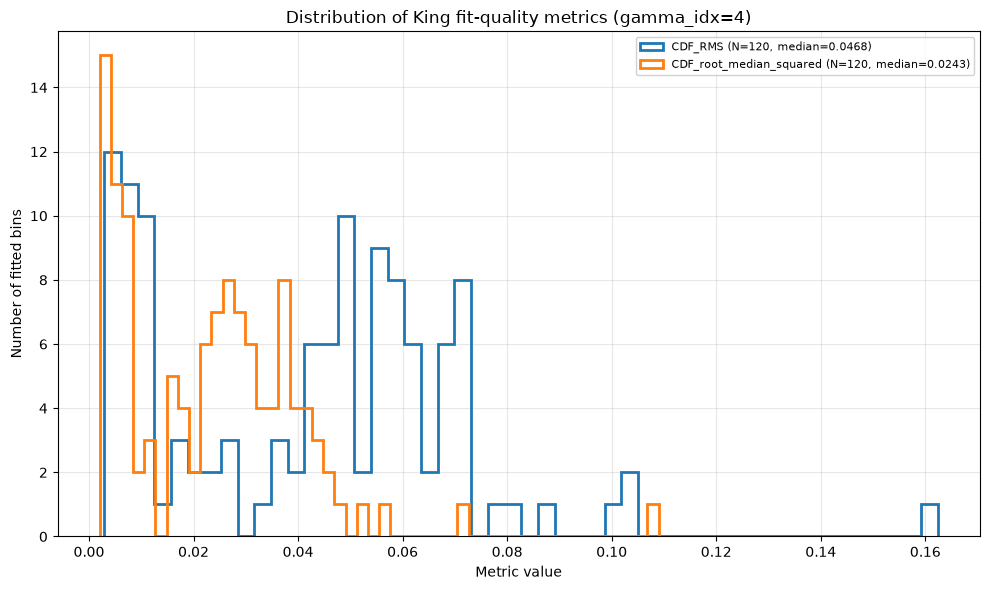

In [29]:
metric_values = fplt.plot_fit_metric_statistics(
    fit_parameters,
    king_wrapper.king_pdf,
    density = False,
    metrics=[
        "CDF_RMS",
        "CDF_root_median_squared",
        #"CDF_density_weighted_rms",
        #'PDF_RMS', 
        #'PDF_root_median_squared'
    ],
    gamma_idx= gamma_idx,
    minimum_counts= cfg['minimum_counts'],
    bins=50,
)

## 1. Removing outliers

Rather than just removing extreme absolute values for alpha and beta, it makes more sense to remove local relative outliers. Also including the fit chi2 could be interesting.

